In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from scipy.integrate import simpson as simps
import os

from scipy.integrate import trapezoid

from scipy.interpolate import Akima1DInterpolator

from scipy.interpolate import PchipInterpolator

In [19]:
Observed_Data = pd.read_excel('F:\P-529990 Joydeppur Iswardi Double Rail Line\Model For B#23 Boral River\Boundary\Observe Discharge From SMZ.xlsx')

h0 = 2
Observed_Data['h_minus_h0'] = Observed_Data['WL_mMSL'] - h0

Observed_Data.head()

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\rbe\AppData\Local\Temp\ipykernel_22532\2523348327.py:1: SyntaxWarning: invalid escape sequence '\P'
  Observed_Data = pd.read_excel('F:\P-529990 Joydeppur Iswardi Double Rail Line\Model For B#23 Boral River\Boundary\Observe Discharge From SMZ.xlsx')


,Date,WL_mMSL,Discharge cumec,h_minus_h0
0,1998-06-03 09:00:00,7.30,11.57,5.30
1,1998-06-17 09:00:00,9.05,26.93,7.05
2,1998-07-03 09:00:00,9.41,67.79,7.41
3,1998-07-15 09:00:00,10.46,95.84,8.46
4,1998-07-28 09:00:00,11.04,176.37,9.04


# Split data at transition stage = 6 m

In [20]:
transition_stage = 6

low_stage = Observed_Data[Observed_Data['WL_mMSL'] < transition_stage]
high_stage = Observed_Data[Observed_Data['WL_mMSL'] >= transition_stage]

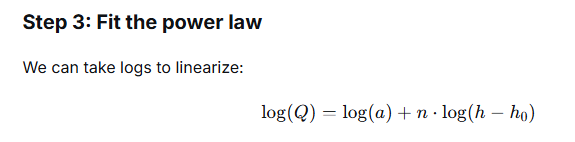

In [21]:
import numpy as np

def fit_stage_discharge(df):
    if len(df) < 2:
        return None, None
    x = np.log(df['h_minus_h0'])
    y = np.log(df['Discharge cumec'])
    # Simple linear regression
    n, log_a = np.polyfit(x, y, 1)
    a = np.exp(log_a)
    return a, n

a_low, n_low = fit_stage_discharge(low_stage)
a_high, n_high = fit_stage_discharge(high_stage)

In [22]:
def predict_Q(h, h0=2, transition=6, a_low=None, n_low=None, a_high=None, n_high=None):
    if h < h0:
        return 0.0
    elif h < transition:
        if a_low is None:
            return np.nan
        return a_low * (h - h0) ** n_low
    else:
        if a_high is None:
            return np.nan
        return a_high * (h - h0) ** n_high

# Example:
h_test = 7.5
Q_test = predict_Q(h_test, h0, transition_stage, a_low, n_low, a_high, n_high)

# n

In [23]:
import pandas as pd

file_path = r'F:\P-529990 Joydeppur Iswardi Double Rail Line\Model For B#23 Boral River\Boundary\WL_Data_All_Flood_Event_Year.xlsx'

# Read all sheets into a dictionary
dfs = pd.read_excel(file_path, sheet_name=None)

# Convert Date column in each sheet
for name, df in dfs.items():
    df['Date'] = pd.to_datetime(df['Date'])

# Access individual sheets
WL_1988_100yr = dfs['1988 100yr']
WL_2017_50yr  = dfs['2017 50yr']
WL_2004_25yr  = dfs['2004 25yr']
WL_2008_2_33yr = dfs['2008 2.33yr']
WL_2020_Clib = dfs['Calibration 2020']


In [28]:
# From earlier observed discharge data
# observed_file = r'F:\P-529999 Joydepour Iswardi Double Rail Line\Model For B#23 Boral River\Boundary\Observe Discharge From SMZ.xlsx'
# Observed_Data = pd.read_excel(observed_file)

Observed_Data = pd.read_excel('F:\P-529990 Joydeppur Iswardi Double Rail Line\Model For B#23 Boral River\Boundary\Observe Discharge From SMZ.xlsx')

# Parameters
h0 = 2
transition_stage = 6

# Add (h - h0)
Observed_Data['h_minus_h0'] = Observed_Data['WL_mMSL'] - h0

# Split at transition stage
low_stage = Observed_Data[Observed_Data['WL_mMSL'] < transition_stage]
high_stage = Observed_Data[Observed_Data['WL_mMSL'] >= transition_stage]

import numpy as np

def fit_stage_discharge(df):
    if len(df) < 2:
        return None, None
    x = np.log(df['h_minus_h0'])
    y = np.log(df['Discharge cumec'])
    n, log_a = np.polyfit(x, y, 1)  # y = n*x + log_a
    a = np.exp(log_a)
    return a, n

a_low, n_low = fit_stage_discharge(low_stage)
a_high, n_high = fit_stage_discharge(high_stage)

print("Low-stage: a =", a_low, "n =", n_low)
print("High-stage: a =", a_high, "n =", n_high)

<>:5: SyntaxWarning: invalid escape sequence '\P'
<>:5: SyntaxWarning: invalid escape sequence '\P'
C:\Users\rbe\AppData\Local\Temp\ipykernel_22532\4238407033.py:5: SyntaxWarning: invalid escape sequence '\P'
  Observed_Data = pd.read_excel('F:\P-529990 Joydeppur Iswardi Double Rail Line\Model For B#23 Boral River\Boundary\Observe Discharge From SMZ.xlsx')


Low-stage: a = 25.813518535828052 n = 0.42103854059973905
High-stage: a = 6.383571052183878 n = 1.3319864472978493


In [30]:
def calculate_discharge(h, h0=2, transition=6, a_low=None, n_low=None, a_high=None, n_high=None):
    if h < h0:
        return 0.0
    elif h < transition:
        if a_low is None:
            return np.nan
        return a_low * (h - h0) ** n_low
    else:
        if a_high is None:
            return np.nan
        return a_high * (h - h0) ** n_high

# Vectorized version for pandas
calculate_discharge_vec = np.vectorize(calculate_discharge)

In [31]:
# List of WL dataframes
wl_datasets = {
    '1988_100yr': WL_1988_100yr,
    '2017_50yr': WL_2017_50yr,
    '2004_25yr': WL_2004_25yr,
    '2008_2_33yr': WL_2008_2_33yr,
    '2020_Calib': WL_2020_Clib
}

for name, df in wl_datasets.items():
    # Assuming water level column is 'WL_mMSL'
    df['Discharge_cumec'] = calculate_discharge_vec(
        df['WL_mMSL'], h0, transition_stage, a_low, n_low, a_high, n_high
    )
    print(f"{name} - Discharge added")

1988_100yr - Discharge added
2017_50yr - Discharge added
2004_25yr - Discharge added
2008_2_33yr - Discharge added
2020_Calib - Discharge added


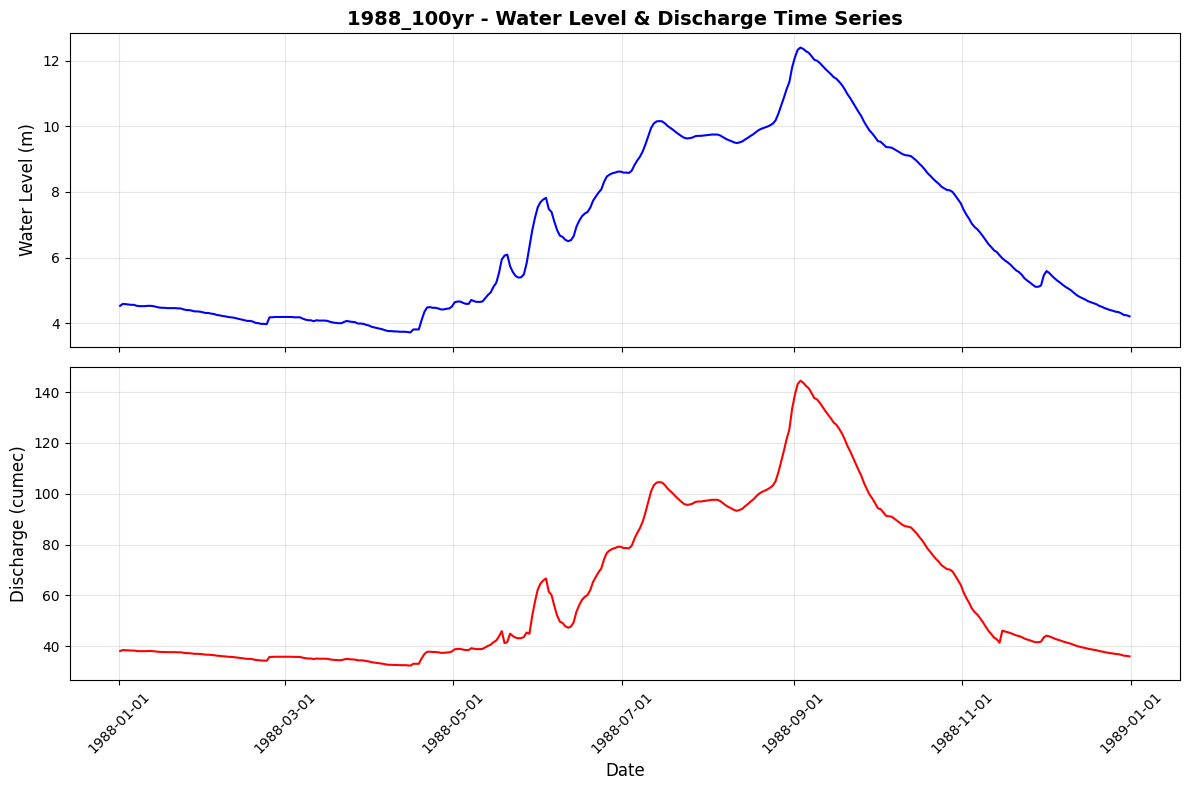


1988_100yr:
  Max Water Level: 12.40 m on 1988-09-03 12:00:00
  Max Discharge: 144.46 cumec on 1988-09-03 12:00:00
--------------------------------------------------


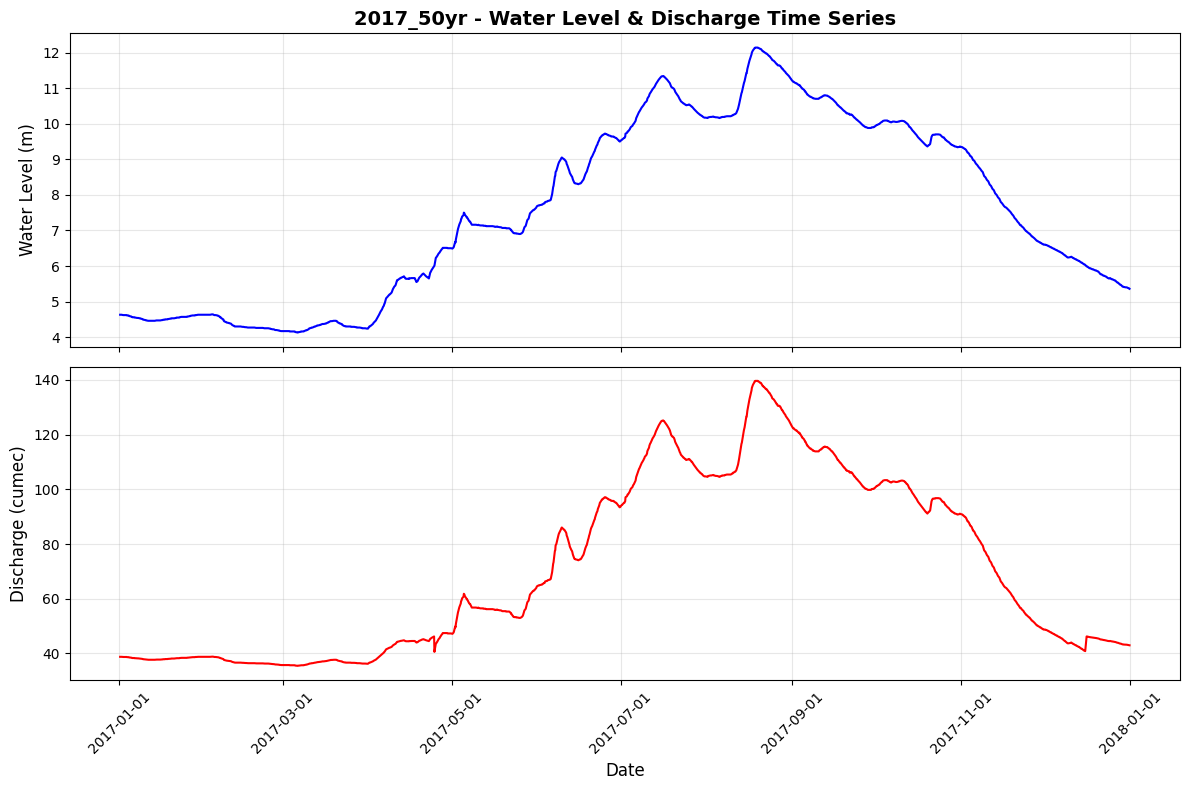


2017_50yr:
  Max Water Level: 12.14 m on 2017-08-18 15:00:00
  Max Discharge: 139.67 cumec on 2017-08-18 15:00:00
--------------------------------------------------


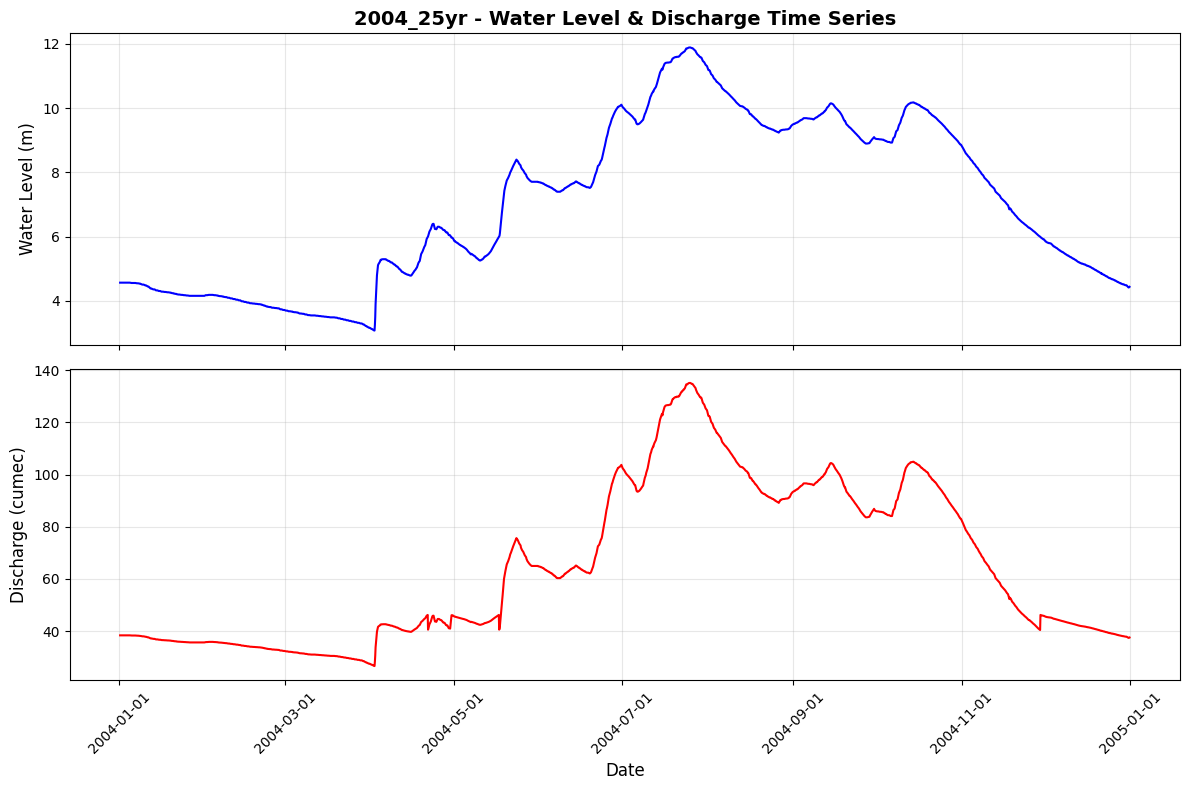


2004_25yr:
  Max Water Level: 11.89 m on 2004-07-25 06:00:00
  Max Discharge: 135.10 cumec on 2004-07-25 06:00:00
--------------------------------------------------


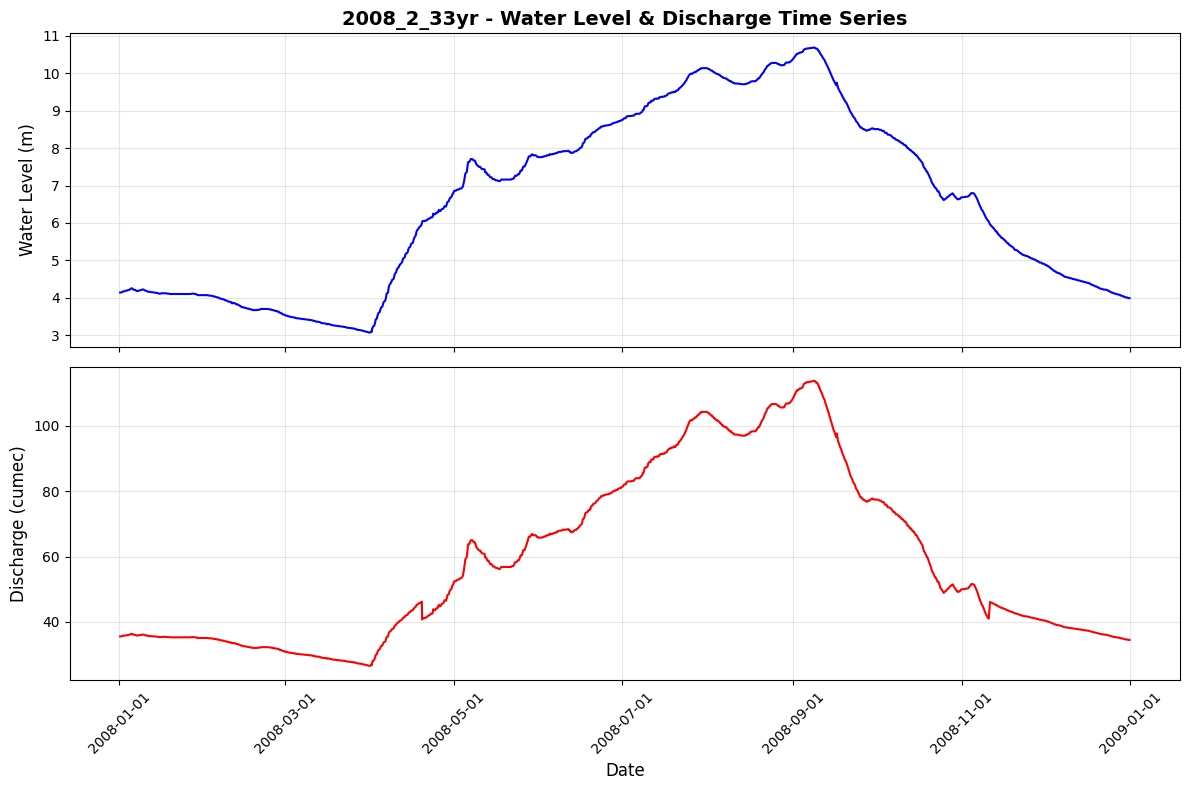


2008_2_33yr:
  Max Water Level: 10.69 m on 2008-09-08 06:00:00
  Max Discharge: 113.72 cumec on 2008-09-08 06:00:00
--------------------------------------------------


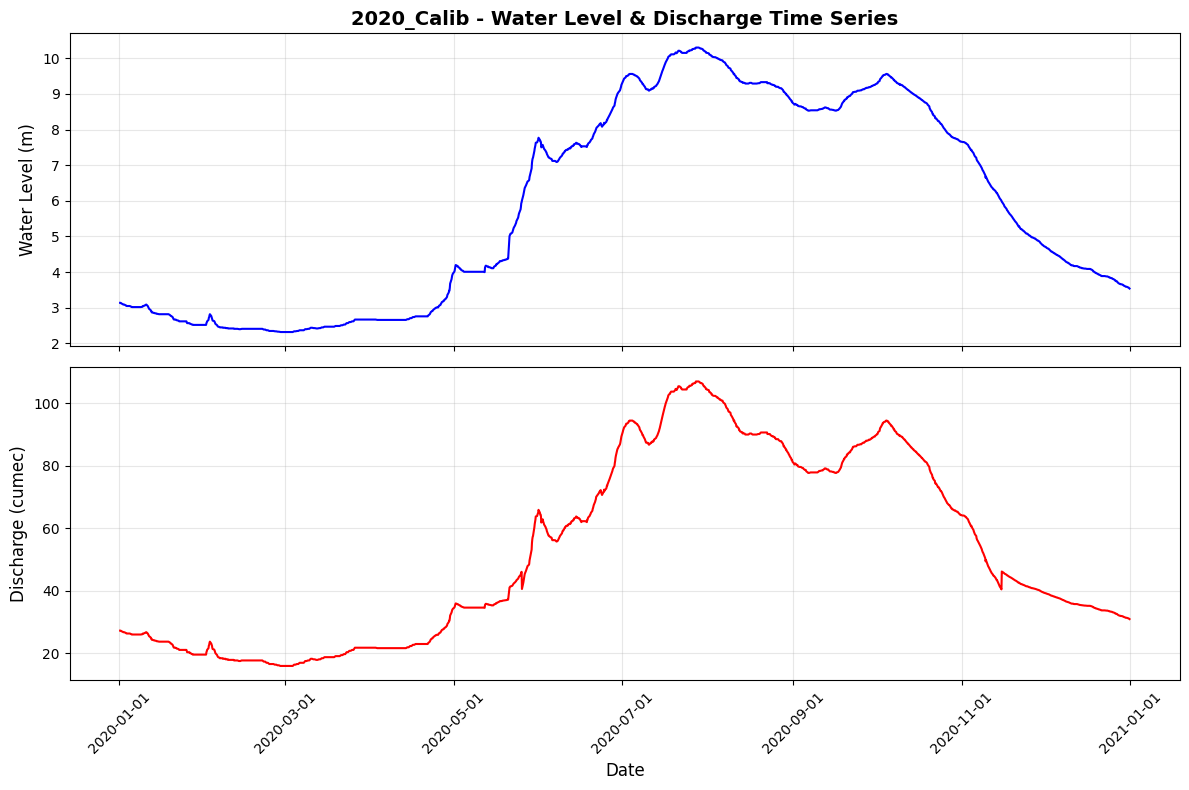


2020_Calib:
  Max Water Level: 10.30 m on 2020-07-27 18:00:00
  Max Discharge: 106.97 cumec on 2020-07-27 18:00:00
--------------------------------------------------


In [32]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Define the datasets with their titles
datasets = {
    '1988_100yr': WL_1988_100yr,
    '2017_50yr': WL_2017_50yr,
    '2004_25yr': WL_2004_25yr,
    '2008_2_33yr': WL_2008_2_33yr,
    '2020_Calib': WL_2020_Clib
}

# Create separate plots for each dataset
for name, df in datasets.items():
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Plot Water Level
    ax1.plot(df['Date'], df['WL_mMSL'], color='blue', linewidth=1.5)
    ax1.set_ylabel('Water Level (m)', fontsize=12)
    ax1.set_title(f'{name} - Water Level & Discharge Time Series', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Plot Discharge
    ax2.plot(df['Date'], df['Discharge_cumec'], color='red', linewidth=1.5)
    ax2.set_ylabel('Discharge (cumec)', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    # Format x-axis dates
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print max values for this dataset
    max_wl = df['WL_mMSL'].max()
    max_discharge = df['Discharge_cumec'].max()
    max_wl_date = df.loc[df['WL_mMSL'].idxmax(), 'Date']
    max_discharge_date = df.loc[df['Discharge_cumec'].idxmax(), 'Date']
    
    print(f"\n{name}:")
    print(f"  Max Water Level: {max_wl:.2f} m on {max_wl_date}")
    print(f"  Max Discharge: {max_discharge:.2f} cumec on {max_discharge_date}")
    print("-" * 50)